# Quant Course: Lesson 1


## Brownian motion and Stochastic integrals 


### Assets and investing


<div>
<img style="float: right;"src="images/invest.png" width="150" />
</div>
Money that is not needed for immediate consumption must be stored for later use. It may be kept in the form:

- cash
- savings account
- invested in government bond, corporate bonds, stocks, crypto, etc.

Any item that can be used to store value will be referred to as an **asset**. Some assets are safe
in the sense that their future value can be predicted quite accurately; other assets
are risky and may bring large gains or severe losses. 

What is **investing?**

The process of taking an ownership position in an asset with the goal of receiving a positive return by appreciation of the asset value.


It is convenient to use the following
assumptions:
1. Assets are measured in units; the price of an asset refers to the price per unit
2. The value of a combination of assets - **portfolio** is the sum of the values of its constituent parts
3. Assets can be traded freely, without transaction costs, at any time and in any quantity
4. The price process is not impacted by the investor’s trades
5. Holding a fixed quantity of an asset brings no costs or dividends


A portfolio is **self-financing** if the investor does not take out money from, and does not invest money to the portfolio after time 0.

In words, this says that the portfolio value at time $t_{j+1}$ is equal to the value at
time $t_j$ plus the gains or losses that have been realized on the assets that constitute
the portfolio. 

We would like to monitor the **value** of the portfolio through a given time interval.



We consider two notions of value:
- **price** (determined by markets), how much money you have to spend to take ownership of the asset based on what is trading at markets
- **fair value** (correct value), what the price of the asset should be (connected to risk neutral measure, arbitrage considerations)










<div>
<img style="float: right;"src="images/derivative.png" width="150" />
</div>

The huge universe of assets is usually divided into two categories:
- **cash products**: stocks, bonds, currencies, commodities
- **derivatives**: forwards, futures, swaps, options

**Derivatives**: A derivative is an asset linked to (or "derived" from) another asset, called the **underlying** asset

In some cases we are able to derive pricing formulas based on arbitrage considerations, without implementing model for the price of the assets. 

If we would like to price more complex instruments, for example options and other credit derivatives, we will need a model for the asset price.

**Target**: come up with a continuous model that mimics the behaviour of stock prices on the market. 
This model will be based on **stochastic processes**. 



As an example let's look at the cruid oil prices for the last 25 years until 11th of February from Trading Economics:

https://tradingeconomics.com/commodity/crude-oil

<div>
<img src="images/crudeoil.jpg" width="800" />
</div>



### What is a stochastic process?

Some ideas that capture the essence of stochatis process:
- random evolution
- random function
- random path

Heuristically : a stochastic or random process is a mathematical object usually defined as a sequence of random variables $X_t$ in a probability space, where the index of the sequence often has the interpretation of time.

$ X_0,X_1, X_2, X_3,  . . . $



### Let's start building this process by Coin tossing 

<div>
<img src="images/200ft.png" width="50"
     alt="alt_text" align="righ"/>
</div>

Our first idea is to model the price of an asset with a process that moves up 1 or down by 1 with equal probability. Let's see the behaviour of this process.



The dynamics can be modelled as follows:
1. We start at 0.
2. At time 1, flip a coin. If head, price goes from 0 to 1. If tails, from 0 to -1.
3. At time 2, starting from the new position (+1 or -1) flip the same coin again and move either up or down according to step 2.
4. Repeat for $n$ steps.

Denote the jth move by $X_t$:

$P(X_t=1)=0.5$, $P(X_t=-1)=0.5$ and $S_n=\sum_{t=0}^n X_t$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

def randomwalk1D(n):

    coin = [-1, 1] #Tails and head

    # Randomly select either UP or DOWN
    steps = np.random.choice(coin, size=(1,n))
        
    # Sum up the values
    path = np.cumsum(steps)
    # Add the starting point
    path = np.concatenate([[0], path])
        
    return path

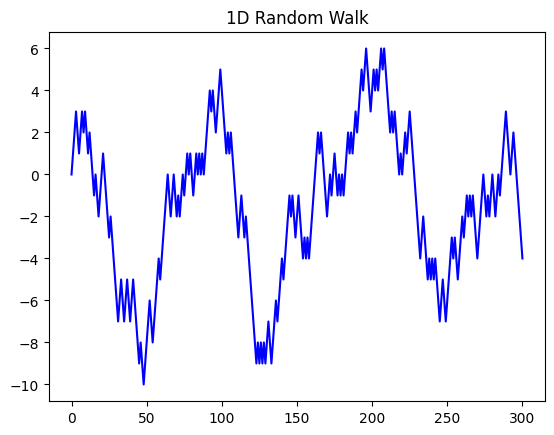

In [4]:
path = randomwalk1D(300)

plt.plot(path, 'b-')
plt.title("1D Random Walk")
plt.show()

### Let's look at the properties of this process:

Let's take a partion of the interval $0=t_0 < t_1 < \dots < t_n = T$.

The discrete-time stochastic process $S_{t_0}, S_{t_1}, S_{t_2}, \dots $ satisfies for any time:
- independent increments: $(S_{t_1}-S_{t_0}), (S_{t_2}-S_{t_1}), (S_{t_3}-S_{t_2}), \dots$
- $E(S_{t_{i+1}}-S_{t_i})=0$
- variance accumulates at rate one per unit time: $Var(S_{t_{i+1}}-S_{t_i})= t_{i+1}-t_i$



In [5]:
mean = lambda x: round(np.mean(x),3)
[mean(time_slice) for time_slice in path[1:10]]

[1.0, 2.0, 3.0, 2.0, 1.0, 2.0, 3.0, 2.0, 3.0]

In [6]:
variance = lambda x: round(np.var(x),3)
[variance(time_slice) for time_slice in path[1:10]]

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

#### What did we miss?

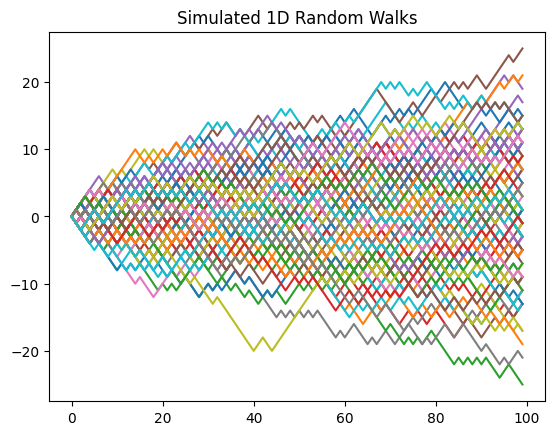

In [28]:
sim = 100
M = np.empty((sim, 0))
for k in range(0, sim, 1):
    pos_data = randomwalk1D(99)
    pos_data = np.array(pos_data).reshape(100,1)
    M = np.hstack((M,pos_data))

plt.plot(M);
plt.title("Simulated 1D Random Walks");

In [8]:
[mean(time_slice) for time_slice in M[1:10]]

[0.14, 0.22, 0.38, 0.38, 0.38, 0.5, 0.72, 0.72, 0.68]

In [9]:
[variance(time_slice) for time_slice in M[1:10]]

[0.98, 1.992, 3.176, 3.896, 5.016, 6.27, 6.002, 7.002, 7.418]

### Problems with the current model:
<div>
<img style="float: left;" src="images/crudeoil.jpg" width="350" />
<img style="float: right;" src="images/1Drandomwalk.png" width="350" />
</div>





1. Discreteness: we usually think of an asset price as something evolving continously in time, at least while markets are open.

2. Fixed unit increment: random walks only moves by a fixed unit. Asset prices can move by almost any dollar amount at all.


3. Fails to replicate:  variance can increase very fast, doesn't take into accound trends, random walk tends to have negative values  


### Adressing the discreteness:


These observations suggest that we might find a better model by taking some kind of limiting case of the random walk as the size of the moves gets smaller but the frequency of the moves increase.

If we choose the time step to be infinitely small the variance goes to infinity. We have to scale down or shrink the size of moves.



<div>
<img style="float: left;"src="images/sheeps.png" width="150" />
</div>

Central Limit Theorem (CLT) states that the distribution of sample means approximates a normal distribution as the sample size gets larger, regardless of the population's distribution.

If we take the mean of $X_1, X_2, X_3, ...$ sequence of i.i.d. random variables with $\mu$ mean and finite variance $\sigma^2$ and substract the mean, divide it by it's standard diviation it would converge to a normal distribution.

$$ \frac{\overline{X_n} - \mu}{\sigma} \rightarrow N(0,1) \text{ ,} n\rightarrow \infty$$



Let's choose $\alpha = \sqrt{n}$ scaling factor and look at:

$$ S_t^{(n)}=\sum_{i=1}^{\lfloor nt \rfloor}\frac{X_i}{\sqrt{n}} $$

In [21]:
import math

def scaledrandomwalk1D(n):
    t=10
    # Generate steps for time point [1, 2, 3, ... , n*t]
    coin_scaled = [-1/np.sqrt(n), 1/np.sqrt(n)] #Tails and head with scaling
        
    # Randomly select either UP or DOWN
    steps = np.random.choice(coin_scaled, size=(1,n*t))
        
    # Sum up the values
    path = np.cumsum(steps)
    # Add the starting point
    paths = np.concatenate([[0], path])
        
    return paths

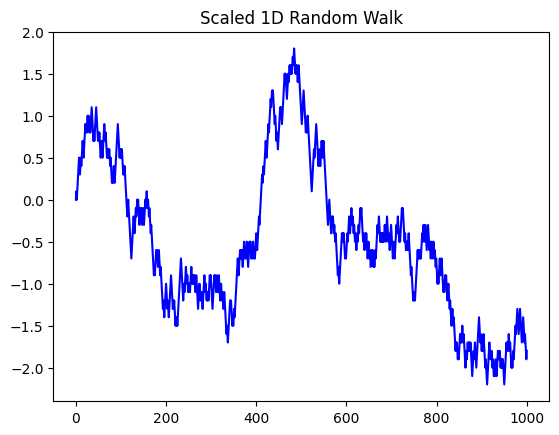

In [22]:
path = scaledrandomwalk1D(100)

plt.plot(path, 'b-')
plt.title("Scaled 1D Random Walk")
plt.show()

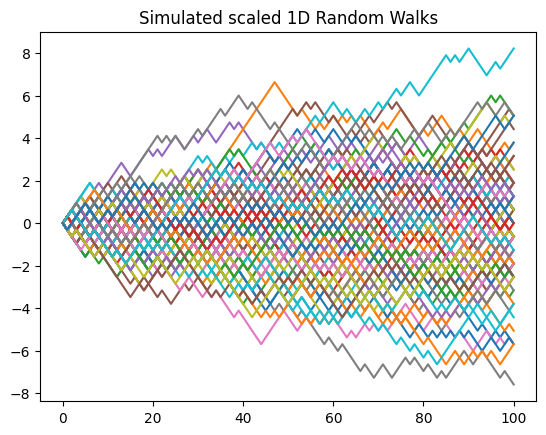

In [33]:
sim = 101
Mscaled = np.empty((sim, 0))
for k in range(0, sim, 1):
    pos_data = scaledrandomwalk1D(10)
    pos_data = np.array(pos_data).reshape(101,1)
    Mscaled = np.hstack((Mscaled,pos_data))
    
plt.plot(Mscaled);
plt.title("Simulated scaled 1D Random Walks");

In [34]:
[mean(time_slice) for time_slice in Mscaled[1:10]]

[-0.022, -0.006, 0.016, -0.0, -0.028, -0.038, -0.041, -0.063, -0.122]

In [35]:
[variance(time_slice) for time_slice in M[1:10]]

[0.99, 2.27, 2.96, 3.826, 4.142, 5.092, 6.062, 7.122, 7.816]

### Is it converging to something sensible?

### Yes, from Donsker's theorem we know that it is converging to a Brownian motion (Wiener process) as $ n \rightarrow \infty $.

$$ S_t^{(n)} \rightarrow W_t$$

In the sense of "weak convergence of stochastic processes".

Definition: **Brownian motion** is a continous time stochastic process, conventionally denoted as $W_t$ or $B_t$ with the following properties:

Let's take a partition  of the interval: $0< t_0 < t_1 < \dots < t_{n-1} < t_{n} = T$:

1. $W_0$ = 0
2. independent increments: $(W_{t_1}-W_{t_0}), (W_{t_2}-W_{t_1}), (W_{t_3}-W_{t_3}), \dots $
3. the distribution of the increments is normal: $W_{t_2}-W_{t_1} \sim N(0,t_2-t_1)$ for any $t_1<t_2$
4. has continous sample paths (almost surely)

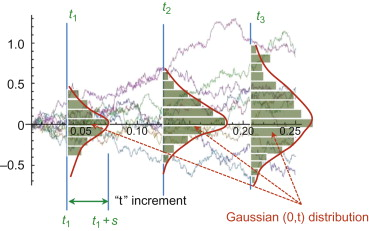
                                                                                     

### Further properties:

Let's take a partition  of the interval: $0< t_0 < t_1 < \dots < t_{n-1} < t_{n}  = T$
- does not have bounded variation for an arbitrary small partion of the interval:
$$ \sum_{i=0}^{n} |W_{t_{i+1}} - W_{t_{i}}| \rightarrow \infty $$
- a stronger property is also true: is nowhere differentiable!

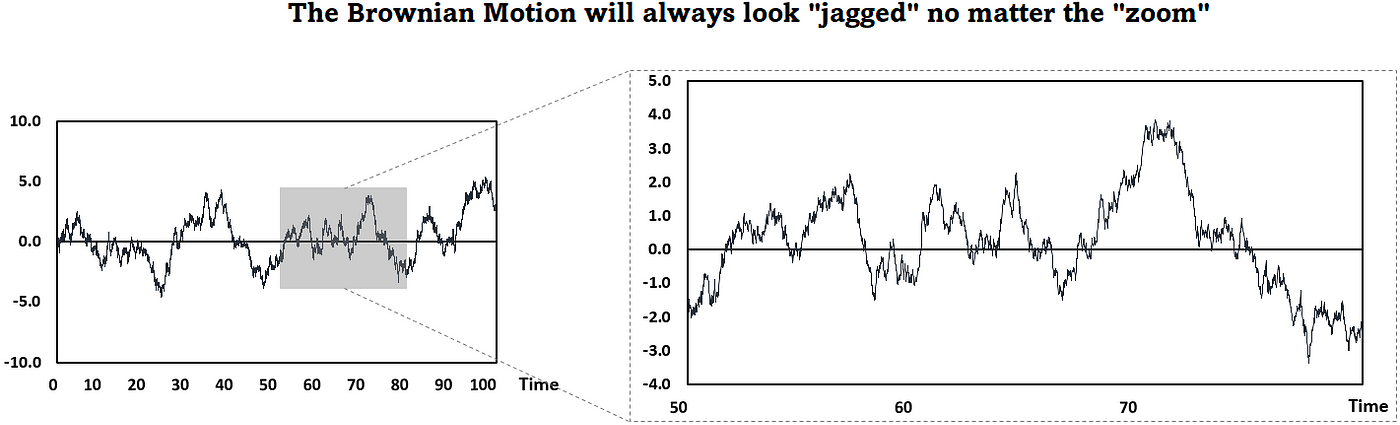

### Further properties:
 For a partion $P$ of the interval $0< t_0 < t_1 < \dots < t_{n-1} < t_{n} = T$
- Wiener process has bounded quadratic variation:
$$ Q_{P} := \sum_{i=0}^n (W_{t_{i+1}} - W_{t_{i}})^2$$
then
$$ E(Q_P) := lim_{n \rightarrow \infty}  \sum_{i=0}^n (W_{t_{i+1}} - W_{t_{i}})^2 = T$$

 In other words, the Wiener process accumulates quadratic variation at a rate of one unit per time.  
 
 This is perhaps surprising result because it can be any path. It doesn't matter how the "infinitely fast" coin flips land, the sum of the square increments will always approach the length of the interval. 

In [36]:
def brownianmotion(n):
    t = 100 # time
    dt = t/n # time step

    # Simulate normal distributed variable
    steps = np.random.normal(0, np.sqrt(dt), size=(1,n-1))
        
    # Sum up the values
    path = np.cumsum(steps)
    # Add the starting point
    paths =  np.append([0],path)
        
    return paths

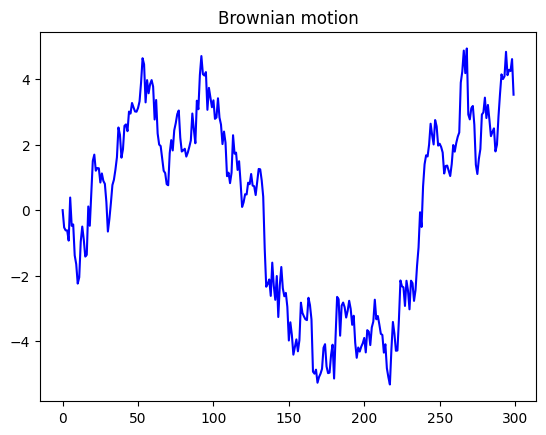

In [41]:
bm = brownianmotion(300)
plt.plot(bm, 'b-');
plt.title("Brownian motion");

In [42]:
sim = 100
bm_paths = np.empty((sim, 0))
for k in range(0, sim, 1):
    bm = brownianmotion(100)
    bm = np.array(bm).reshape(100,1)
    bm_paths = np.hstack((bm_paths,bm))

In [43]:
[mean(time_slice) for time_slice in bm_paths[1:10]]

[0.104, 0.133, 0.106, 0.137, 0.012, 0.079, 0.279, 0.173, 0.126]

In [44]:
[variance(time_slice) for time_slice in bm_paths[1:10]]

[1.374, 2.589, 3.477, 4.117, 5.146, 5.904, 7.184, 8.119, 9.567]

In [45]:
quadratic_variation = lambda x: round(np.square(x[:-1]-x[1:]).sum(),3)
[quadratic_variation(time_slice) for time_slice in bm_paths.T[:10]]

[106.607,
 83.914,
 101.684,
 100.219,
 122.699,
 89.561,
 103.321,
 107.169,
 88.927,
 77.392]

### Problems with the current model:

1. Discreteness: solved

2. Fixed unit increment: solved

3. Fails to replicate: 

- variance can increase very fast:mostly solved

- doesn't take into accound trends 

- random walk tend to have negative values 

- size of the moves does not scale with the price level 
( a \$10 move is just as likely for an asset trading at 15 as one trading at 250)







### Adding a trend

We want to think that the company (hence the asset price) is going to grow. 

Add a term to the Brownian motion that represents a trend and a volatility factor:

$$W_{t; \mu, \sigma} = \mu t + \sigma W_t$$

This will be called **Brownian motion with a drift**, with $\mu t $ drift and $\sigma $ volatility.

Note that $\mu$ and $\sigma$ can also be time dependent.

<div>
<img src="images/browniandrift.jpg" width="450" />
</div>

##### Non-negative values and moves that scale with price level?

### Scaling and negative price

#### Idea:

Let's condiser and model changes in $\log (S_t)$ and let $\psi(t) = log(S_t)$. 

$$ S_t = e^{\psi (t)}$$

Price is non-negative.



If $ \psi (t+1)= \psi (t) + \delta $ then
$$ S_{t+1} = e^{\psi (t+1)} = e^{\psi(t)+\delta} = e^{\delta}e^{\psi(t)} = e^{\delta}S_t$$

This is a multiplicative updating, scales with price.  So the price change can be written:

$$ S_{t+1} - S_t = e^{\delta}S_t - S_t = (e^{\delta}-1)S_t $$

So a fixed additive move in $\log (S_t)$ implies a price move that scales with price level.

These considerations lead us to consider modelling $\log(S_t)$ as a Brownian motion rather than $S_t$ itself:

$$ \log(S_t) = \mu t + \sigma W_t $$


                


Also, an initial value $S_0$ should be included:

$$ \log(S_t) = \log(S_0) + \mu t + \sigma W_t$$

We exponenciate both sides:
 
$$ S_t = S_0  e^{\mu t + \sigma W_t} $$

This model is called the **Geometric Brownian motion**.

### Is it good enough?

In [46]:
import math

def geometricbrownianmotion(n, S0, mu, sigma, t):
    dt = t/n # time step

    # Simulate the variable
    St = np.exp(
        (mu-sigma**2/2)*dt + sigma * np.random.normal(0, np.sqrt(dt), size=(1,n)).T
    )
    #include array of 1's
    St = np.vstack([np.ones(1), St])

    # Move the object 
    St = S0 * St.cumprod(axis=0)
        
    time = np.linspace(0,t, n+1)
    
    return time, St


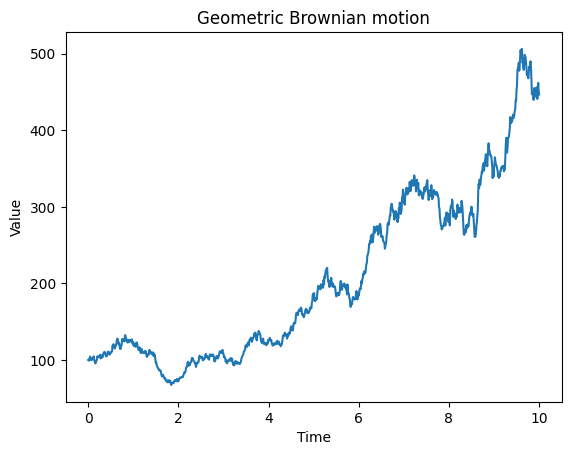

In [47]:
mu = 0.1
sigma = 0.2
S0 = 100
n = 1000 #increase n
t=10
tt, St = geometricbrownianmotion(n, S0, mu, sigma, t)
plt.plot(tt, St) ;
plt.title("Geometric Brownian motion")
plt.xlabel("Time");
plt.ylabel("Value");

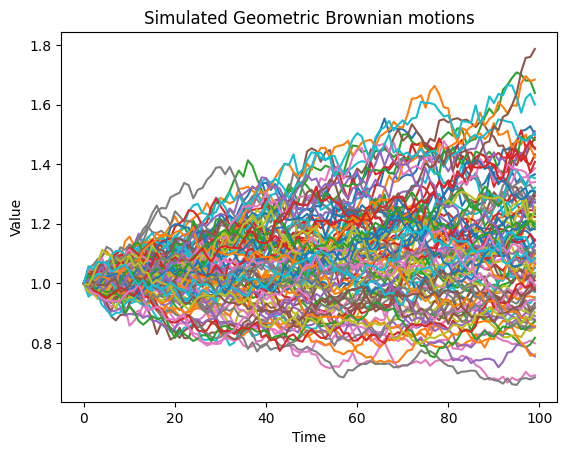

In [48]:
sim = 100
gbm_paths = np.empty((sim, 0))
for k in range(0, sim, 1):
    tt, gbm = geometricbrownianmotion(99, 1, 0.15, 0.2, 1)
    gbm_paths = np.hstack((gbm_paths,gbm))
plt.plot(gbm_paths);
plt.title("Simulated Geometric Brownian motions")
plt.xlabel("Time");
plt.ylabel("Value");

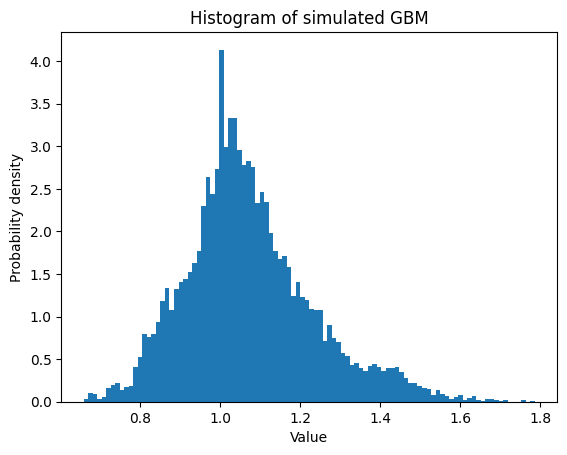

In [49]:
#plot histogram
gbm_paths = np.array(gbm_paths).reshape(sim*sim,1)
plt.title("Histogram of simulated GBM", loc='center')
plt.xlabel("Value")
plt.ylabel("Probability density")
plt.hist(gbm_paths, bins=100, density=True)
plt.show()

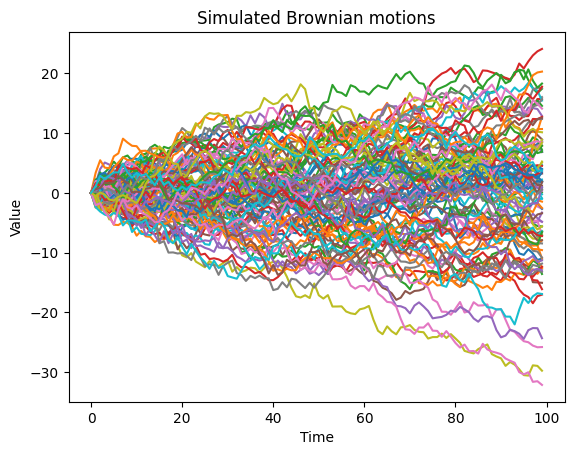

In [50]:
plt.plot(bm_paths);
plt.title("Simulated Brownian motions")
plt.xlabel("Time");
plt.ylabel("Value");

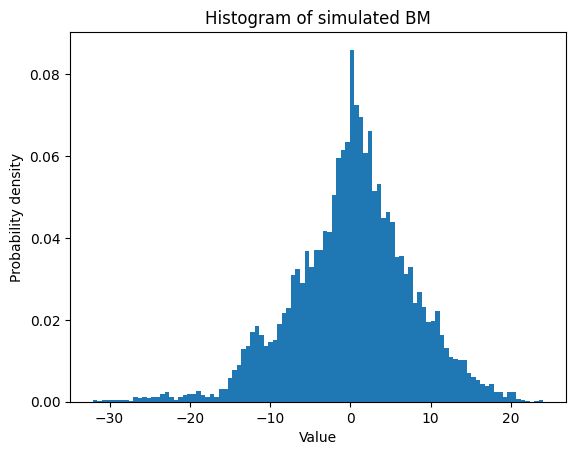

In [51]:
#plot histogram
bm_paths = np.array(bm_paths).reshape(sim*sim,1)
plt.title("Histogram of simulated BM", loc='center')
plt.xlabel("Value")
plt.ylabel("Probability density")
plt.hist(bm_paths, bins=100, density=True)
plt.show()

Initially we wanted to model the value of the portfolio.

If we take $ S_t = S_0  e^{\mu t + \sigma W_t} $ the change (**derivative**) in the asset price

$$ \frac{d S_t}{dt} = \left[ \mu + \sigma \frac{d W_t}{dt}\right] S_0  e ^{\mu t + \sigma W_t} =  \left[\mu + \sigma \frac{dW_t}{dt}\right] S_t = \mu S_t + \sigma S_t \frac{d W_t}{dt} $$




    
In differential form:

$$ d S_t = \mu S_t dt  + \sigma S_t d W_t$$

### What is the derivative of the Brownian motion?

<div>
<img style="float: right;" src="images/derivate.png" width="300"/>
<img style="float: left;" src="images/integral.png" width="300"/>
</div>

### Stochastic calculus

- Problems: Brownian motion is not differentiable at any given point
- Ordinary calculus: Differentiation (gradient) $\rightarrow$ Integration (area)
- Stochastic calculus: Ordinary calculus + randomness, Integration $\rightarrow$ Differentiation 

- How to define:
$$ \int_{0}^{T} S_t d W_t = ? $$

- Plots from *Lessons in Industrial Automation*





### Rieman approach
- $\int_{a}^b f(t)dt$
- partition: 
$$ P_{n} = \{t_{0}, t_1, \dots, t_n\} $$
- sums: 
$$L(P_n, f) = \sum_{i=1}^{n}f(t_{i-1})(t_i - t_{i-1}), U(P_n, t) = \sum_{i=1}^{n}f(t_{i})(t_i - t_{i-1})$$


### Stieltjes approach
- $g(t)$: monotonic and bounded variation
- $\int_{a}^b f(t)dg(t)$
- sums: 
$$L(P_n, f,g) = \sum_{i=1}^{n}f(t_{i-1})(g(t_i) - g(t_{i-1})) $$
$$U(P_n, f,g) = \sum_{i=1}^{n}f(t_{i})(g(t_i) - g(t_{i-1}))$$



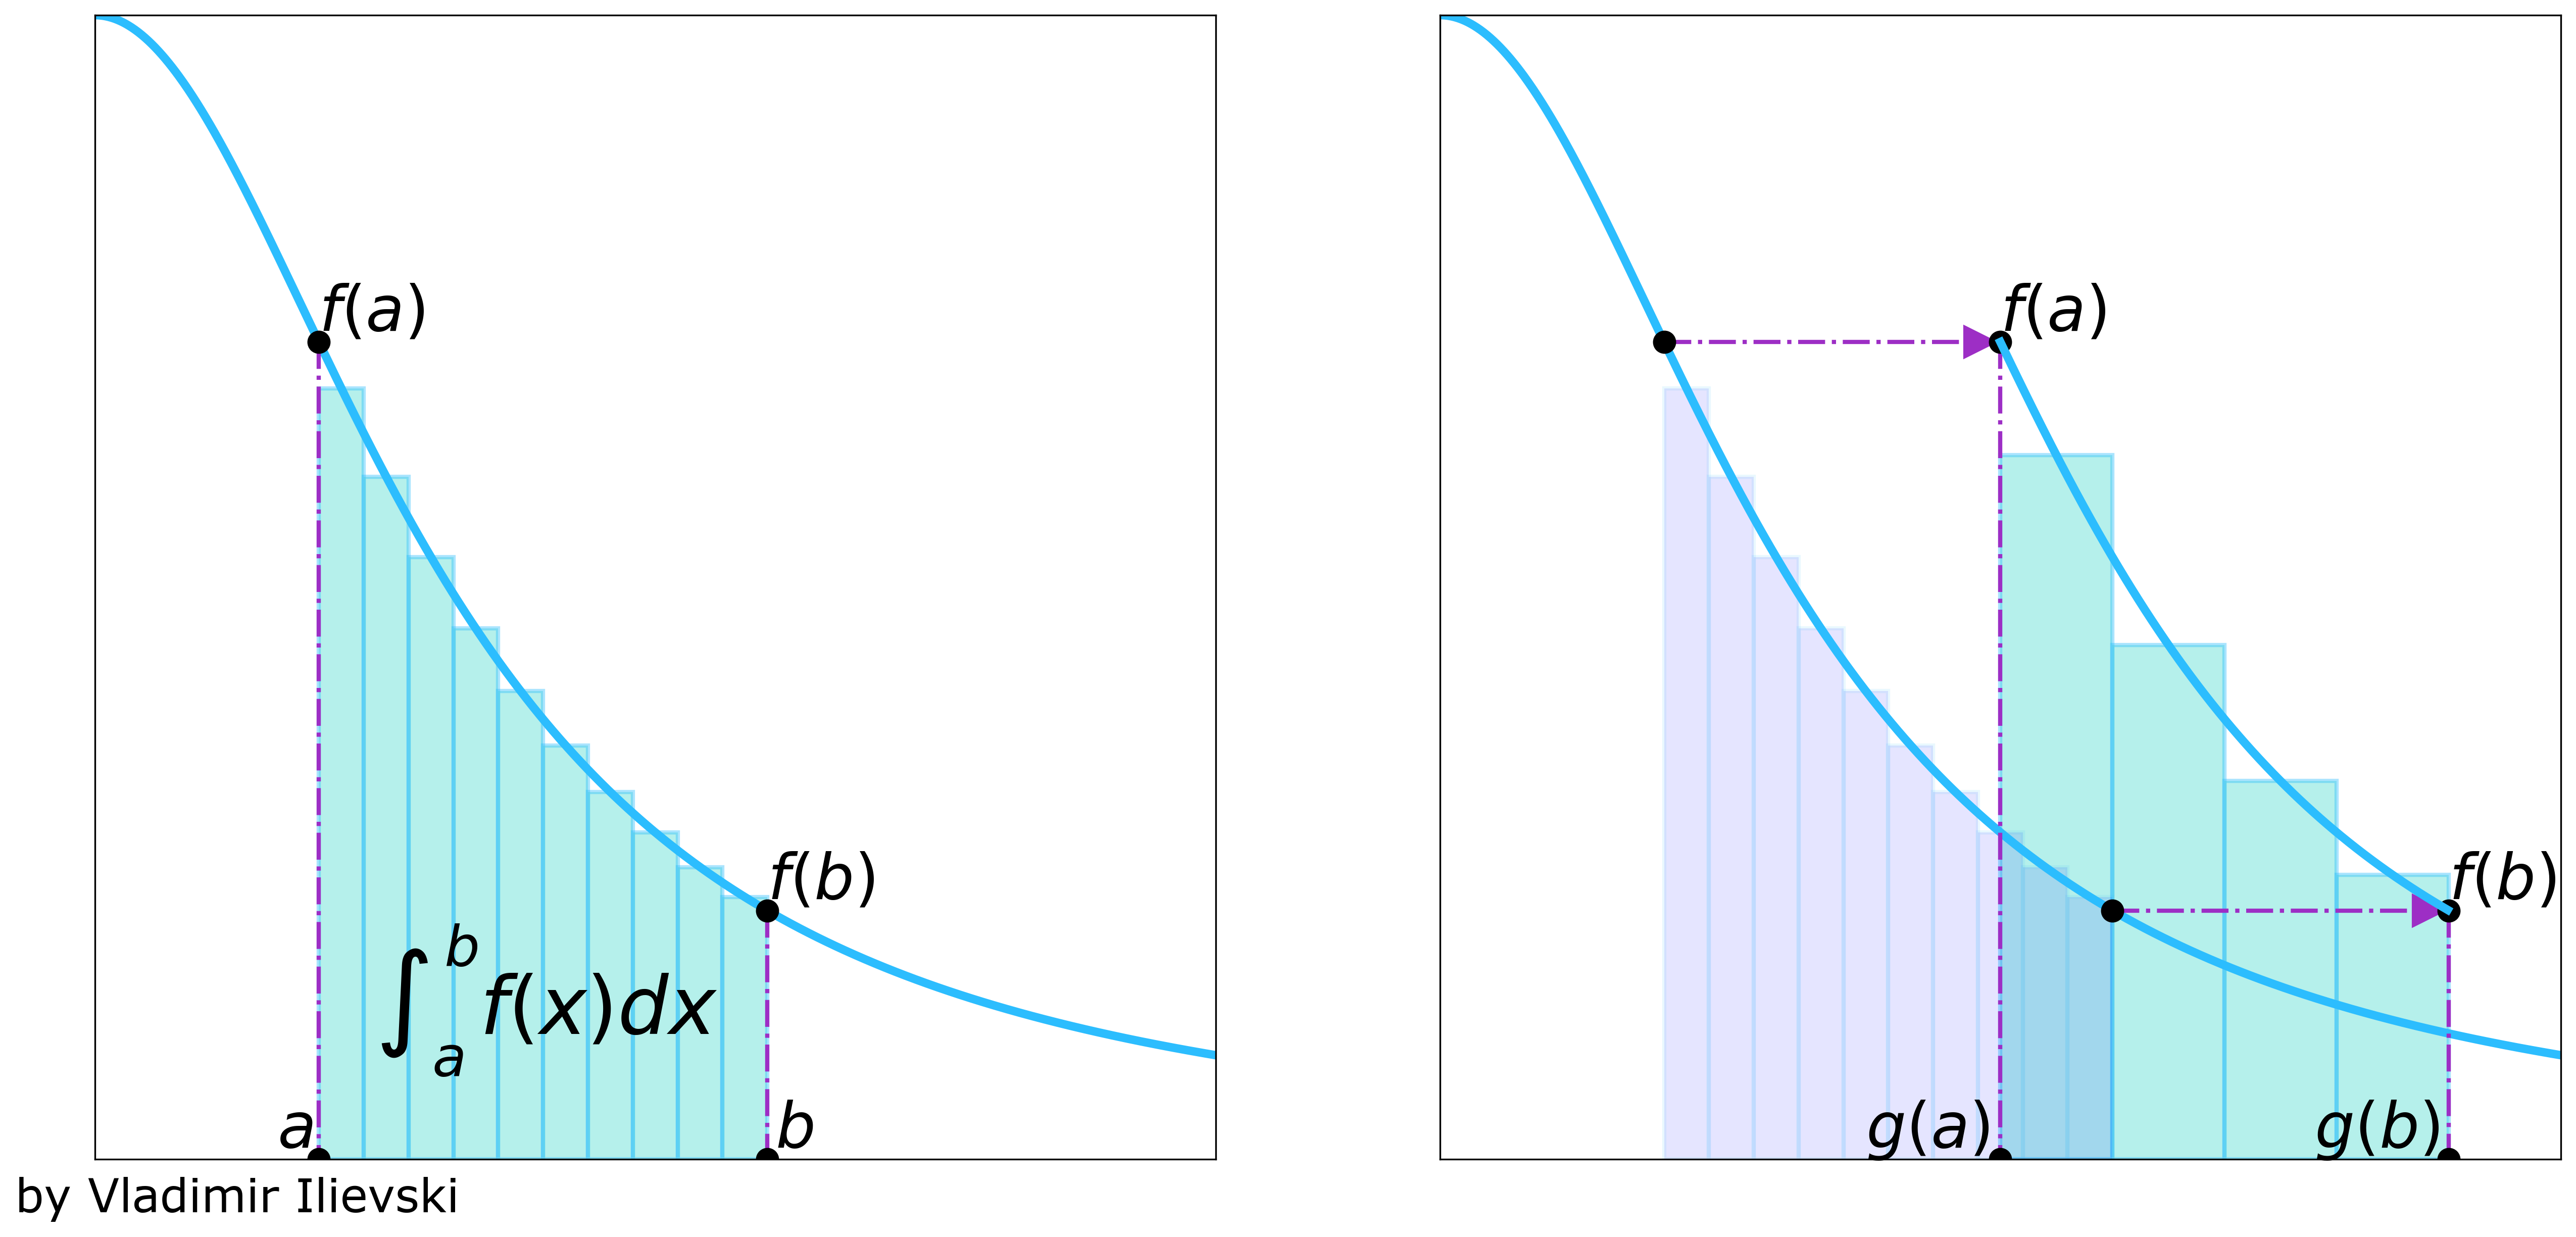

<div>
<img style="float: left;" src="images/stochasticint2.png" width="400"/>
</div>

### Stochastic integral
For any partioning $0 = t_0 < t_1 < \dots < t_n= T $ of the interval $[0, T]$ we can form the sum:

 $$ \sum_{j=0}^n f(t_j) (W_{t_{j+1}} - W_{t_j}) $$
 
 which **defines a random variable**. 


It can be shown that, under suitable continuity and boundedness conditions, these properties guarantee that one can indeed define a stochastic integral by the formula


$$ \int_{0}^{T} f(t) d W_t = \lim_{n \rightarrow \infty} \sum_{j=0}^n f(t_j) (W_{t_{j+1}} - W_{t_j}) $$
 
The limit is understood in the
stochastic sense of convergence in probability.

Basic rules for stochastic integration:
taking $X_t$ and $Y_t$ stochatis processes

1. Telescope rule:
$$ \int_0^T dW_t = W_T - W_0$$

2. Linearity with respect to the integrand:

$$ \int_0^T (a X_t + b Y_t)dW_t  = a \int_0^T X_t dW_t + b \int_0^T Y_t dW_t$$

3. Linearity with respect to the integrator:

$$ \int_0^T  X_t d(a Y_t + b W_t)  = a \int_0^T X_t dY_t + b \int_0^T Y_t dW_t$$



#### Problem: 
Calculation by definition is time consuming and non-trivial.

### Let's go back to ordinary calculus

The Fundamental theorem of calculus says that if $f$ is a differentiable function:

$$f(t)=f(0) + \int_0^T f'(t)dt $$

It states that the two basic operations
of calculus, integration and differentiation, are each other’s inverse. The rule above may also be written in the form:

$$df(t)=f'(t)dt $$


 




This means that the change in $f$ is *proportial* to the change in $t$.
For small changes in the variable, second-order and higher terms are negligible compared to the first-order terms.

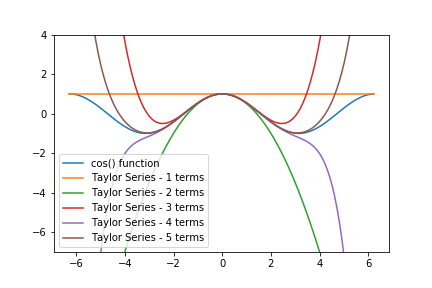



Using Taylor expansion of $f(t)$ around $a$:

$$f(t)=f(a)+(t-a)\frac{\partial f}{\partial t}(a)+\dots$$

$$f(t)-f(a)=(t-a)\frac{\partial f}{\partial t}(a)+\dots$$

$dt$ means change in $t$:

$$dt=\frac{\partial f}{\partial t}dt+\dots$$

As $dt\rightarrow 0$ higher order terms converge to 0: $dt=\frac{\partial f}{\partial t}dt$



### Can we derive a formula for stochastic derivates in a similar way?

If $f(t,x)$ is a twice-differentiable function, using the Taylor series expansion:

$$ df =\frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x}dx +\frac{1}{2}\frac{\partial^2 f}{\partial t^2}dt^2+ \frac{1}{2}\frac{\partial f}{\partial t}\frac{\partial f}{\partial x}dt dx+ \frac{1}{2}\frac{\partial f}{\partial x}\frac{\partial f}{\partial t}dx dt +\frac{1}{2}\frac{\partial^2 f}{\partial x^2}dx^2 +\dots$$

All the second order and higher terms tend to zero much faster than the first order terms and are dropped. So in the limit, this becomes:

$$df =\frac{\partial f}{\partial t}dt+\frac{\partial f}{\partial x}dx$$



Substituting $S_t$ for $x$ we get:

$$ df =\frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial S_t}dS_t +\frac{1}{2}\frac{\partial^2 f}{\partial t^2}dt^2+ \frac{1}{2}\frac{\partial f}{\partial t}\frac{\partial f}{\partial S_t}dt dS_t+ \frac{1}{2}\frac{\partial f}{\partial S_t}\frac{\partial f}{\partial t}dS_t dt +\frac{1}{2}\frac{\partial^2 f}{\partial S_t^2}dS_t^2 +\dots$$

Since $$ dS_t = \mu dt +\sigma dW_t $$

$$ df =\frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial S_t}( \mu dt +\sigma dW_t) +\frac{1}{2}\frac{\partial^2 f}{\partial t^2}dt^2+ \frac{1}{2}\frac{\partial f}{\partial t}\frac{\partial f}{\partial S_t}dt ( \mu dt +\sigma dW_t)+ \frac{1}{2}\frac{\partial f}{\partial S_t}\frac{\partial f}{\partial t}( \mu dt +\sigma dW_t) dt +\frac{1}{2}\frac{\partial^2 f}{\partial S_t^2}( \mu^2 dt^2 + 2\mu \sigma dt dW_t +\sigma^2 dW_t^2) +\dots$$

> Rules of stochastic calculus:
> - $(dW_t)^2 = dt$
> - $dt dW_t = 0$
> - $(dt)^2=0$

$$df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial S_t}( \mu dt +\sigma dW_t)  +\frac{1}{2}\frac{\partial^2 f}{\partial S_t^2}(\sigma^2 dt) $$

$$ df(S_t) = \mu \frac{\partial f}{\partial S_t}(S_t)dt  +\sigma \frac{\partial f}{\partial S_t}(S_t) dW_t +\frac{1}{2} \sigma^2 \frac{\partial^2 f}{\partial S_t^2}(S_t) dt $$

### Ito process

In the general case we will be interested in a special class of stochastic processes called **Ito drift diffusion processes**:

$$ S_t = X_0 + \int_0^T \mu_t dt+ \int_0^T \sigma_t dW_t $$

where the first term is a Riemann integral (drift term) and the second one is a stochastic integral (diffusion term).

In differential form:

$$ dS_t = \mu_t dt +\sigma_t dW_t $$

If $f(t)$ is a twice continously differentiable function:
$$ df(S_t) = \big( \mu_t f'(S_t)   +\frac{1}{2} \sigma_t^2 f''(S_t)\big)dt +\sigma_t f'(S_t) dW_t $$

Which in integral form:



$$f(S_T) = f(S_0) + \int_0^T \Big( \mu_ t f'(S_t)dt +  \frac{1}{2} \int_0^T \sigma_t^2 f''(S_t) \Big) dt + \int_0^T \sigma_ t f'(S_t)dW_t  $$






Is called **Ito's formula (Ito's lemma)**. Sometimes referred as stochatic version of the chain rule.


$$ df(S_t) = \Big( \mu_t \frac{\partial f}{\partial S_t} +\frac{1}{2} \sigma_t^2 \frac{\partial^2 f}{\partial S_t^2}\Big) dt  +\sigma_t \frac{\partial f}{\partial S_t} dW_t  $$

### Let's see an example

$$\int_0^T W_t dW_t=?$$

We know that: $f(S_T) = f(S_0) + \int_0^T \Big( \mu_ t f'(S_t)dt +  \frac{1}{2} \int_0^T \sigma_t^2 f''(S_t) \Big) dt + \int_0^T \sigma_ t f'(S_t)dW_t  $




Let us represent the Brownian motion as an Ito process:

$ \mu_t = 0$, $\sigma_t=1$ and $f(t)=t^2$, $S_t=W_t$

$$W_T^2 = W_0^2 + \int_0^T \Big(  0\cdot 2 W_t  +\frac{1}{2} \int_0^T 2 \Big)dt + \int_0^T 2 W_t d W_t  $$


$W_0 = 0,  \int_0^T dt = T $, so we get:

$$\int_0^T W_t dW_t = \frac{1}{2}(W_T^2-T)$$

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation Parameters
T = 1.0        # Total time
dt = 0.0005    # Fine time steps for better convergence
steps = int(T / dt)
t = np.linspace(0, T, steps)

# 2. Generate Brownian Motion (W_t)
np.random.seed(42)
dW = np.random.normal(0, np.sqrt(dt), steps)
W = np.cumsum(dW)

# 3. Target: Calculate the Integral of W_t dW_t
# We will compare the theoretical Ito result vs the 'naive' Calculus result

# A. The Itô Result (From your derivation): 0.5 * (W_t^2 - t)
ito_integral_theory = 0.5 * (W**2 - t)

# B. The 'Standard' Calculus Guess (Incorrect): 0.5 * W_t^2
standard_calc_guess = 0.5 * W**2

# C. Numerical Integration (Simulating the 'physical' process)
# Summing W_t * dW_t step-by-step
numerical_sum = np.zeros(steps)
for i in range(1, steps):
    numerical_sum[i] = numerical_sum[i-1] + W[i-1] * dW[i]



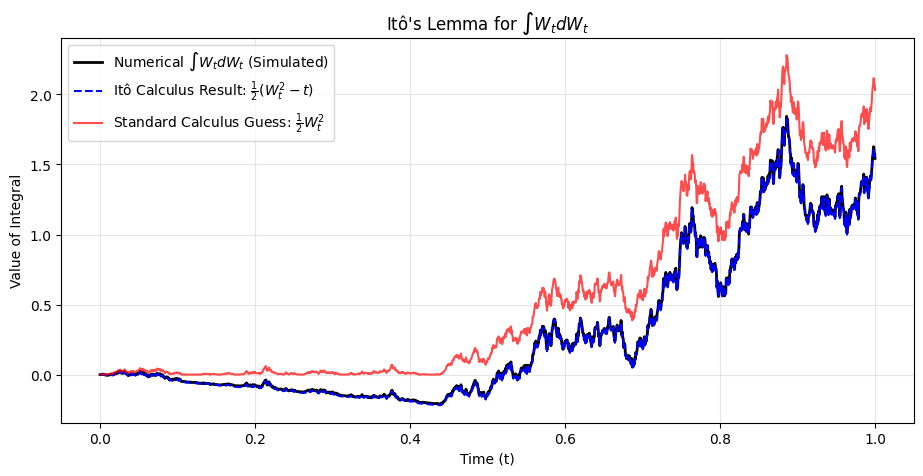

In [53]:
plt.figure(figsize=(11, 5))
plt.plot(t, numerical_sum, label="Numerical $\int W_t dW_t$ (Simulated)", color='black', lw=2)
plt.plot(t, ito_integral_theory, label="Itô Calculus Result: $\\frac{1}{2}(W_t^2 - t)$", color='blue', linestyle='--')
plt.plot(t, standard_calc_guess, label="Standard Calculus Guess: $\\frac{1}{2}W_t^2$", color='red', alpha=0.7)
plt.title("Itô's Lemma for $\int W_t dW_t$")
plt.xlabel("Time (t)")
plt.ylabel("Value of Integral")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Another example - interest rate model

We start with an SDE for mean reversion:
    $$ d r_t = \theta(\mu -r_t)dt + \sigma dW_t $$
    
We know that: $df = \frac{\partial f }{\partial t} dt + \frac{\partial f}{\partial r} d r_t + \frac{1}{2}\frac{\partial^2 f}{\partial r^2} (d r_t)^2$ 


We define: $f(t) = r_t e^{\theta t}$

- $\frac{\delta f}{\delta t} = \theta r_t e^{\theta t}$
- $\frac{\delta f}{\delta r} = e^{\theta t}$
- $\frac{\delta^2 f}{\delta r^2}=0$
 
 $$ d(r^t e^{\theta t}) = (\theta r_t e^{\theta t})dt + e^{\theta t} [\theta(\mu - r_t)dt + \sigma dW_t]$$
 
 $$ d(r^t e^{\theta t}) = \theta r_t e^{\theta t} dt + \theta \mu e^{\theta t} dt -\theta r_t e^{\theta t}dt + \sigma e^{\theta t}dW_t $$
 
 $$ d(r^t e^{\theta t}) = \theta \mu e^{\theta t} dt + \sigma e^{\theta t}dW_t $$
 


 Now we move to the integral from 0 to T:
 
 $$ r^T e^{\theta T} = r_0 + \int_0^T \theta \mu e^{\theta t} dt + \int_0^T \sigma e^{\theta t} dW_t$$
 
 $$ r_T  = r_0 e^{-\theta T} + \mu (1-e^{-\theta T}) + \sigma \int_0^T e^{- \theta (T-t)}dW_t$$

Few things to note as time $T$ increases:
- the exponential term $e^{-\theta t}$ gets smaller. the "memory" of the initial state fades
- $1-e^{-\theta T}$ approaches 1, this will ensure that in the long run, the average value process will be $\mu$
- the stochastic integral part has zero expectation


In [54]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters for the OU 
r0 = 0.03      # Initial Interest Rate (3%)
theta = 0.1    # Rate of mean reversion (how fast it pulls back)
mu = 0.05      # The "Long-term" mean rate (5%)
sigma = 0.02   # Volatility
T = 5.0        # Simulate over 5 years
dt = 0.01
steps = int(T / dt)
t = np.linspace(0, T, steps)

# 2. Simulate the Path
# dr_t = theta * (mu - r_t) * dt + sigma * dW_t
r = np.zeros(steps)
r[0] = r0
np.random.seed(123)

for i in range(1, steps):
    dr = theta * (mu - r[i-1]) * dt + sigma * np.random.normal(0, np.sqrt(dt))
    r[i] = r[i-1] + dr

# 3. Use Ito's Lemma to Plot the "Expected Path"
# From the solution of the SDE: E[r_t] = r0*e^(-theta*t) + mu*(1 - e^(-theta*t))
expected_path = r0 * np.exp(-theta * t) + mu * (1 - np.exp(-theta * t))


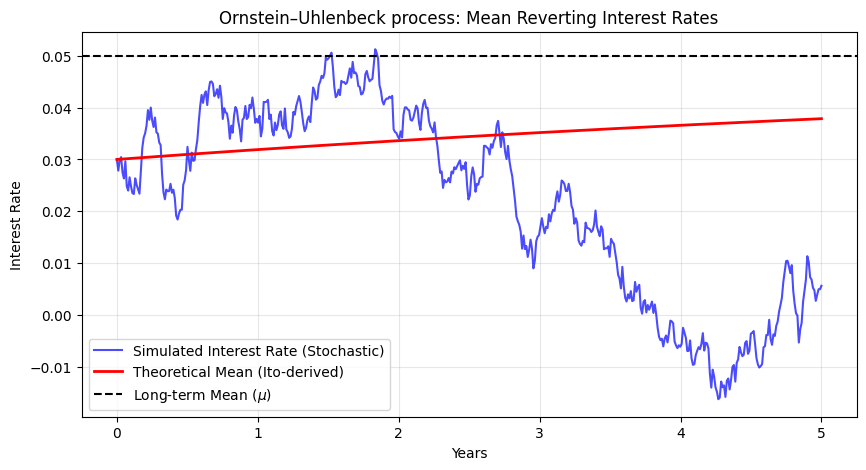

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(t, r, label="Simulated Interest Rate (Stochastic)", color='blue', alpha=0.7)
plt.plot(t, expected_path, label="Theoretical Mean (Ito-derived)", color='red', lw=2)
plt.axhline(mu, color='black', linestyle='--', label="Long-term Mean ($\mu$)")
plt.title("Ornstein–Uhlenbeck process: Mean Reverting Interest Rates")
plt.xlabel("Years")
plt.ylabel("Interest Rate") 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.show()

### Summary


- model the asset price:

$$log(S_t) = \mu t +\sigma W_t $$

$$S_t = S_0 e^{\mu t +\sigma W_t} $$

- changes in the asset price can be viewed as:

$$dS_t = \mu S_t + \sigma S_t dW_t$$



### Summary

- define integration with respect to a stochastic process:



$$\int_0^T X_tdW_t = \lim_{n \rightarrow \infty} \sum_{j=0}^n X_{t_j}(W_{t_{j+1}}-W_{t_j})$$


- when $S_t$ is a drift diffusion process Ito's rule can be used to calculate the derivate:

$$f(S_T) = f(S_0) + \int_0^T \Big( \mu_ t f'(S_t)dt +  \frac{1}{2} \int_0^T \sigma_t^2 f''(S_t) \Big) dt + \int_0^T \sigma_ t f'(S_t)dW_t  $$

### We have a model for the asset price and a way to calculate changes in the portfolio value !!!

### References

- Cameron Connell, *Financial Derivatives course*, accessed on 2023 August

- Peter Kevei, *Financial mathematics lecture notes* (University of Szeged, 2020)

- QuantPy youtube channel, accessed on 2023 August

- Schumacher, J. M., *Introduction to Financial Derivatives*, (Open Press TiU, 2020)

- Tony R. Kuphaldt, *Lessons in Industrial Automation*, Control Aumation, accessed on 2023 August

- Vladimir Ilievsky, *Integrals are Fun - Illustrated Riemann-Stieltjes Integral*, iSquared, accessed on 2023 August




